# PDO and NINO indices
Niño 1+2 (0-10S, 90W-80W):  The Niño 1+2 region is the smallest and eastern-most of the Niño SST regions, and corresponds with the region of coastal South America where El Niño was first recognized by the local populations.  This index tends to have the largest variance of the Niño SST indices.

Niño 3 (5N-5S, 150W-90W):  This region was once the primary focus for monitoring and predicting El Niño, but researchers later learned that the key region for coupled ocean-atmosphere interactions for ENSO lies further west (Trenberth, 1997).  Hence, the Niño 3.4 and ONI became favored for defining El Niño and La Niña events.

Niño 3.4 (5N-5S, 170W-120W):  The  Niño 3.4 anomalies may be thought of as representing the average equatorial SSTs across the Pacific from about the dateline to the South American coast.  The Niño 3.4 index typically uses a 5-month running mean, and El Niño or La  Niña events are defined when the  Niño 3.4 SSTs exceed +/- 0.4C for a period of six months or more.

Niño 4 (5N-5S, 160E-150W): The  Niño 4 index captures SST anomalies in the central equatorial Pacific. This region tends to have less variance than the other Niño regions.

## 0. Set up

### 0.1 Import packages

In [1]:
import os
import re

import bottleneck
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from tqdm import tqdm
import cmocean
from scipy.interpolate import interp1d
import imageio

import pop_tools
# import ocetrac

import dask
import dask_jobqueue
import distributed
import dask.array as da

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### 0.2 Functions

In [2]:
def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices
    
def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths, 
                                 concat_dim='time', 
                                 combine='nested', 
                                 parallel=True)
    return var_ds

def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']
        
    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()
        
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])
            
        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])
        
    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)
    
    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)
    
    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

In [3]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])
    
    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)
    
    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)}) 
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})  
    
    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})
    
    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])
    
    # compute anomalies by removing all  the model coefficients 
    ssta_notrend = sst-model_da.dot(sst_mod)
    
    # Use the 90th percentile as a threshold and find anomalies that exceed it. 
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})
    
    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

def compute_index(selected_anom):
    fanom = selected_anom
    fanomnan = fanom.copy(deep=True)

    ### standardize
    STANDARDIZE = True
    if STANDARDIZE: 
        fosistd = fanom.std('time')
        fosimean = fanom.mean('time')
        fanom = (fanom - fanom.mean('time')) / fanom.std('time')
        
    
    ### fill nans for EOF calc
    fanom = fanom.fillna(0)
    
    ### grab time, spatial coords for later reference
    times = fanom.time
    nnlat = fanom.lat
    nnlon = fanom.lon

    ### SVD method
    # reshape 
    # reshape data
    a, b, c = np.shape(fanom.values)  # have axis sizes for later (a, b, c)
    Y_stand = fanom.values.reshape(a, b*c);
    #Y = fosi_anom[field].values.reshape(a, b*c);
    Y = fanomnan.values.reshape(a, b*c)
    # print('orig shape: ',a, b, c)
    # print('new shape:  ', np.shape(Y_stand))

    Y_stand_ = da.from_array(Y_stand, chunks=(10000, 100)).persist()
    u, s, v = da.linalg.svd(Y_stand_)
    v = v.compute()
    s = s.compute()
    u = u.compute()

    eof_nums=[1,2,3]
    
    ee = []
    zz = []
    for eof_num in eof_nums:
        # Find the eigenvector (e1_svd) associated with "eof_num" from the SVD method
        e1_svd = (v[eof_num-1,:]).reshape(b,c)
    
        # Calculate the principal component (z1_svd) associated with "eof_num" from the SVD method
        z1_svd = u[:,eof_num-1]*(s[eof_num-1])
        ## standardize it
        z1_svd = (z1_svd-np.mean(z1_svd))/np.std(z1_svd)
    
        ee.append(e1_svd)
        zz.append(z1_svd)
    ee = np.array(ee)
    zz = np.array(zz)
    return zz    
def compute_nino34(sst, climatology=None, standardize=True):
    """
    Computes the NINO3.4 index from SST data or anomalies.
    
    Parameters:
    -----------
    sst : xarray.DataArray
        Sea Surface Temperature (time, lat, lon) [°C]. 
        If raw SST, provide `climatology`. If anomalies, set `climatology=None`.
    climatology : xarray.DataArray, optional
        Monthly climatology (month, lat, lon). Required if `sst` is raw SST.
    standardize : bool, optional
        If True, standardizes the index (mean=0, std=1).
        
    Returns:
    --------
    nino34_index : xarray.DataArray
        NINO3.4 index time series.
    """
    # Convert SST to anomalies if climatology is provided
    if climatology is not None:
        sst_anom = sst.groupby('time.month') - climatology
    else:
        sst_anom = sst  # Assume input is already anomalies
    
    # Handle longitude conventions (0°–360° or -180°–180°)
    lon_min, lon_max = 190, 240  # 170°W–120°W in 0°–360°
    if np.any(sst_anom.lon < 0):  # If -180°–180° convention
        lon_min, lon_max = -170, -120
    
    # Select NINO3.4 region (5°N–5°S, 170°W–120°W)
    nino34_region = sst_anom.sel(
        lat=slice(-5, 5),
        lon=slice(lon_min, lon_max)
    )
    
    # Area-weighted average (cosine-latitude weighting)
    weights = np.cos(np.deg2rad(nino34_region.lat))
    nino34_index = (nino34_region * weights).mean(dim=['lat', 'lon'])
    
    # Standardize (if requested)
    if standardize:
        nino34_index = (nino34_index - nino34_index.mean('time')) / nino34_index.std('time')
    
    return nino34_index


## Load data

In [5]:
var = 'SST'
comp = 'atm'

for ens_memb_index in range(5,100):
    print(ens_memb_index)
    directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
    ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index)
    CESMLENS_SST_hist_time_slice = ds_var_hist_SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
    CESMLENS_SST_fut_time_slice = ds_var_fut_SST.sel(time=slice('2015-02-01', '2020-12-01'))
        
    # concatenating the historical and future simulations together to get one dataset from 1979 to 2022
    CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
    
    CESMLENS_SST_ds = CESMLENS_SST_ds.compute()
    CESMLENS_SST_ds_no_nan = CESMLENS_SST_ds.where(CESMLENS_SST_ds != 0, np.nan)
    mean, trend, seas, features_notrend, ssta_notrend = calculate_anomalies_trend_features(ds=CESMLENS_SST_ds_no_nan.SST)
    selected_anom_PDO = ssta_notrend.sel(lat=slice(20, 65), lon=slice(120,260)) # PDO region
    PDO_indices = compute_index(selected_anom_PDO)
    climatology = CESMLENS_SST_ds.SST.groupby('time.month').mean('time')  # 30-year baseline
    nino34 = compute_nino34(CESMLENS_SST_ds.SST, climatology=climatology)
    np.save('data/ens_{}_PDO.npy'.format(ens_memb_index), PDO_indices)
    np.save('data/ens_{}_NINO34.npy'.format(ens_memb_index), nino34.data)


5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

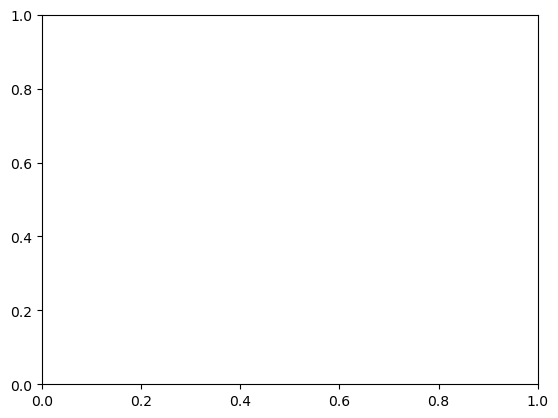

In [19]:
plt.plot(nino34)

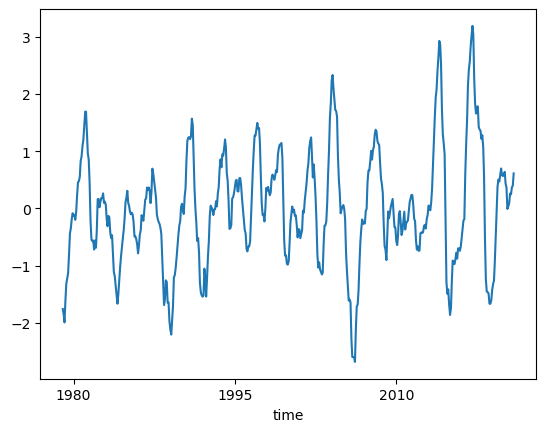

In [28]:
nino34_ls[0].plot()

In [29]:
PDO_indices

array([[ 0.02590087,  0.33996498,  0.20760986, ...,  0.45371381,
         0.53165538,  0.75911192],
       [ 0.97451924,  0.95486388,  0.83602449, ..., -1.71528456,
        -1.45109739, -1.97140909],
       [-0.83100609, -0.06970465,  0.00753481, ..., -0.40316056,
         0.20896043,  1.28811414]])

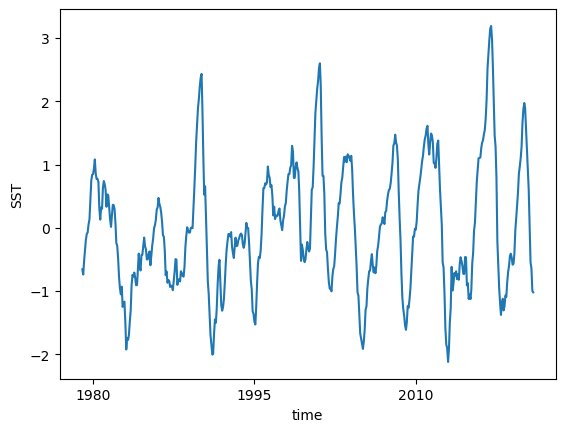

In [23]:
nino34.SST.plot()

In [12]:
PDO_indices.shape

(3, 504)

In [68]:
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.sel(time=slice('2015-02-01', '2020-12-01'))
    
# concatenating the historical and future simulations together to get one dataset from 1979 to 2022
CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')

CESMLENS_SST_ds = CESMLENS_SST_ds.compute()

In [69]:
CESMLENS_SST_ds_no_nan = CESMLENS_SST_ds.where(CESMLENS_SST_ds != 0, np.nan)

In [28]:
mean, trend, seas, features_notrend, ssta_notrend = calculate_anomalies_trend_features(ds=CESMLENS_SST_ds_no_nan.SST)

In [76]:
selected_anom_NINO34 = ssta_notrend.sel(lat=slice(-5, 5), lon=slice(190,240)) # NINO34 region
selected_anom_PDO = ssta_notrend.sel(lat=slice(20, 65), lon=slice(120,260)) # PDO region

In [79]:
NINO34_indices = compute_index(selected_anom_NINO34)
PDO_indices = compute_index(selected_anom_PDO)

In [ ]:
PDO_indices

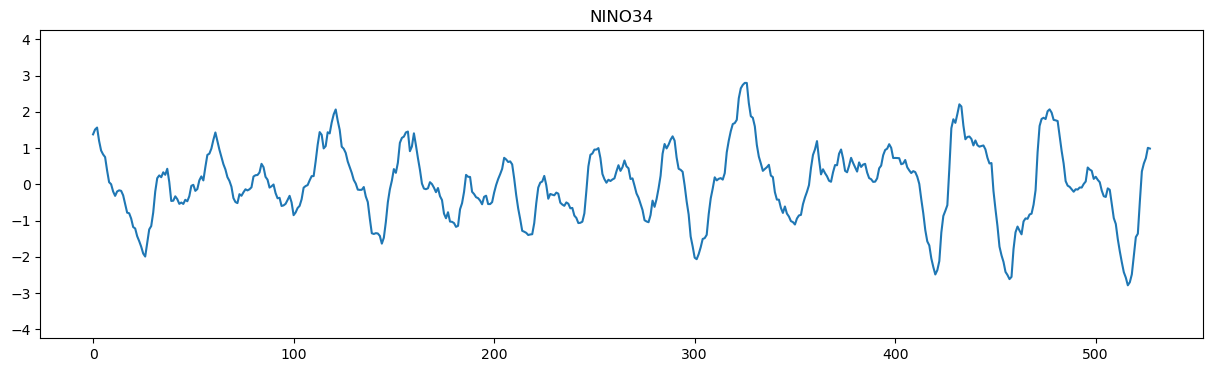

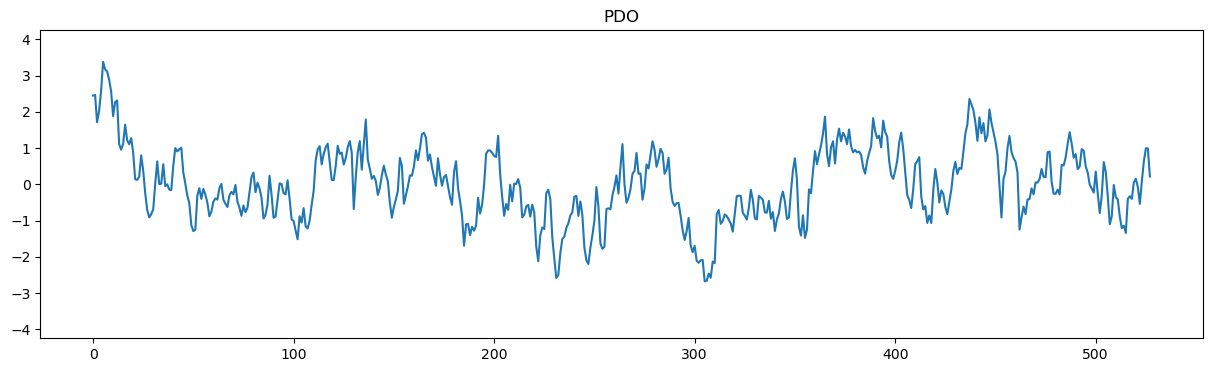

In [80]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), NINO34_indices[0]*-1); plt.title('NINO34'); plt.show()
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), PDO_indices[0]*-1); plt.title('PDO'); plt.show()


In [78]:
def compute_index(selected_anom):
    fanom = selected_anom
    fanomnan = fanom.copy(deep=True)

    ### standardize
    STANDARDIZE = True
    if STANDARDIZE: 
        fosistd = fanom.std('time')
        fosimean = fanom.mean('time')
        fanom = (fanom - fanom.mean('time')) / fanom.std('time')
        
    
    ### fill nans for EOF calc
    fanom = fanom.fillna(0)
    
    ### grab time, spatial coords for later reference
    times = fanom.time
    nnlat = fanom.lat
    nnlon = fanom.lon

    ### SVD method
    # reshape 
    # reshape data
    a, b, c = np.shape(fanom.values)  # have axis sizes for later (a, b, c)
    Y_stand = fanom.values.reshape(a, b*c);
    #Y = fosi_anom[field].values.reshape(a, b*c);
    Y = fanomnan.values.reshape(a, b*c)
    # print('orig shape: ',a, b, c)
    # print('new shape:  ', np.shape(Y_stand))

    Y_stand_ = da.from_array(Y_stand, chunks=(10000, 100)).persist()
    u, s, v = da.linalg.svd(Y_stand_)
    v = v.compute()
    s = s.compute()
    u = u.compute()

    eof_nums=[1,2,3]
    
    ee = []
    zz = []
    for eof_num in eof_nums:
        # Find the eigenvector (e1_svd) associated with "eof_num" from the SVD method
        e1_svd = (v[eof_num-1,:]).reshape(b,c)
    
        # Calculate the principal component (z1_svd) associated with "eof_num" from the SVD method
        z1_svd = u[:,eof_num-1]*(s[eof_num-1])
        ## standardize it
        z1_svd = (z1_svd-np.mean(z1_svd))/np.std(z1_svd)
    
        ee.append(e1_svd)
        zz.append(z1_svd)
    ee = np.array(ee)
    zz = np.array(zz)
    return zz

In [54]:
fanom = selected_anom #anomalies_rm30

In [55]:
### copy fanom for projection later
fanomnan = fanom.copy(deep=True)

### standardize
STANDARDIZE = True
if STANDARDIZE: 
    fosistd = fanom.std('time')
    fosimean = fanom.mean('time')
    fanom = (fanom - fanom.mean('time')) / fanom.std('time')
    

### fill nans for EOF calc
fanom = fanom.fillna(0)

### grab time, spatial coords for later reference
times = fanom.time
nnlat = fanom.lat
nnlon = fanom.lon

In [58]:
### SVD method
# reshape 
# reshape data
a, b, c = np.shape(fanom.values)  # have axis sizes for later (a, b, c)
Y_stand = fanom.values.reshape(a, b*c);
#Y = fosi_anom[field].values.reshape(a, b*c);
Y = fanomnan.values.reshape(a, b*c)
print('orig shape: ',a, b, c)
print('new shape:  ', np.shape(Y_stand))

orig shape:  528 10 41
new shape:   (528, 410)


In [59]:
Y_stand_ = da.from_array(Y_stand, chunks=(10000, 100)).persist()

In [60]:
u, s, v = da.linalg.svd(Y_stand_)

In [61]:
v = v.compute()

In [62]:
s = s.compute()

In [63]:
u = u.compute()

lag1 autocorrelation from np.correlate: 0.965
number of samples: 528
effective sample size: [9.]
variance explained by first three eigenvalues: 94.5%
variance explained by first four eigenvalues:  96.8% 



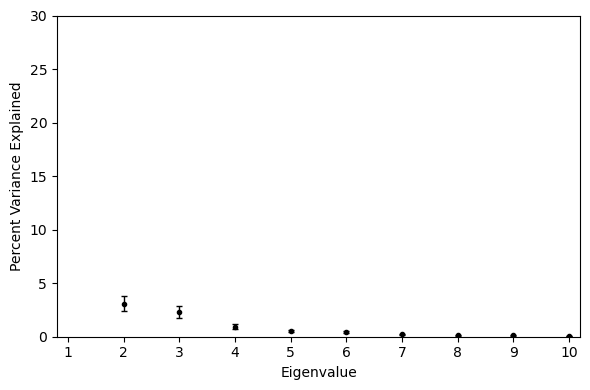

In [64]:
# convert eigenvalues to percent variance explained
pve = 100.*np.abs(s**2)/np.sum(np.abs(s**2))

f=plt.figure(figsize=(6,4))
#plt.plot(np.arange(1,len(pve)+1),pve,label='svd')
plt.ylim([0,30])
plt.xlim([0.8,10.2])
plt.ylabel('Percent Variance Explained')
plt.xlabel('Eigenvalue')
plt.xticks(np.arange(10)+1)
plt.grid(False, axis='x')
#plt.legend()
plt.tight_layout()

# Calculate effective N using lag-1 autocorrelation
# try anoms without fillna...
#tseries=np.nanmean(np.nanmean(fosi_sst[field].values,axis=2),axis=1)
tseries=np.nanmean(np.nanmean(fanomnan.values,axis=2),axis=1)

sigma=np.std(tseries)  ## calculate the standard deviation
mean=np.mean(tseries)  ## calculate the mean
N=len(tseries)         ## calculate the length of the timeseries
lag=1
t1_m=tseries[0:-1*lag]-mean
t2_m=tseries[lag:]-mean
alpha=np.correlate(t1_m,t2_m,mode='valid')/(N-lag)/(sigma**2)
print('lag1 autocorrelation from np.correlate:',round(alpha[0],3))

### Calculate the effective sample size (Nstar) for this data
### To estimate the number of independent samples - use Chapter 2 Barnes Eq. 88
Nstar=np.round((1-alpha)/(1+alpha)*N,0)
print(f'number of samples: {len(tseries)}')
print('effective sample size:',Nstar)
eb = pve*np.sqrt(2./Nstar)  ## North 1982, Barnes Chapter 3 Equation 80

plt.errorbar(np.arange(1, np.size(pve)+1.), pve, yerr=eb/2, xerr=None, \
             capsize=2, elinewidth=1, color='k', fmt='.');
print(f'variance explained by first three eigenvalues: {np.sum(pve[0:2]):0.1f}%')
print(f'variance explained by first four eigenvalues:  {np.sum(pve[0:3]):0.1f}%','\n')

In [65]:
eof_nums=[1,2,3]

ee = []
zz = []
for eof_num in eof_nums:
    # Find the eigenvector (e1_svd) associated with "eof_num" from the SVD method
    e1_svd = (v[eof_num-1,:]).reshape(b,c)

    # Calculate the principal component (z1_svd) associated with "eof_num" from the SVD method
    z1_svd = u[:,eof_num-1]*(s[eof_num-1])
    ## standardize it
    z1_svd = (z1_svd-np.mean(z1_svd))/np.std(z1_svd)

    ee.append(e1_svd)
    zz.append(z1_svd)
ee = np.array(ee)
zz = np.array(zz)

In [72]:
zz.shape

(3, 528)

In [66]:
# first EOF
d1 = (1./np.size(Y, axis=0))*np.dot(np.transpose(zz[0]), Y)  # Barnes Chapter 3 Equation (79)
d1plot = d1.reshape(b, c)  # this is the reshaped eigenvector to plot

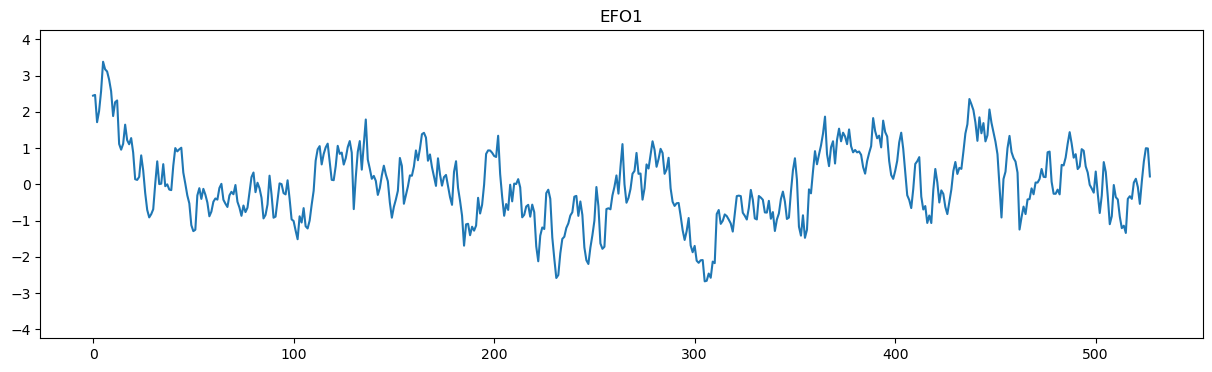

In [51]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()


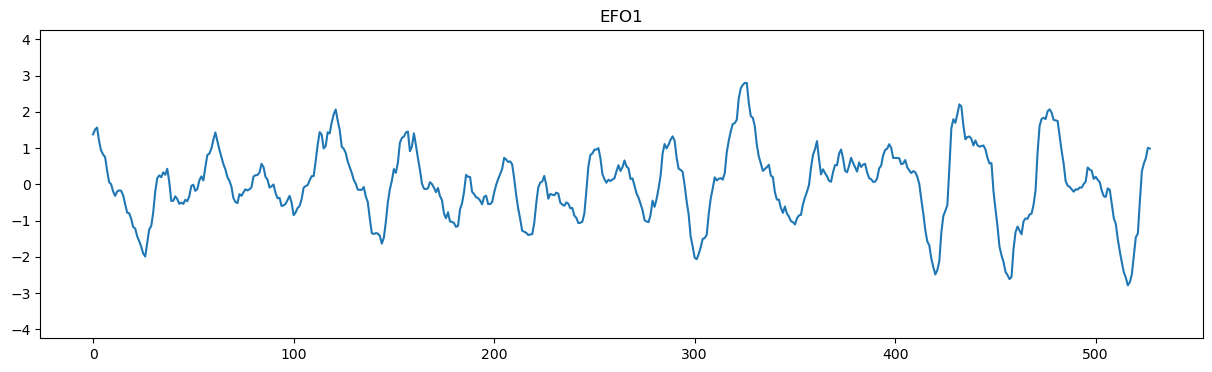

In [67]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()
